<a href="https://colab.research.google.com/github/Bhuvana908/Diabetic-Retinopathy-using-AI-ML-Summer-Research-Internship-NITC-/blob/main/DR4/DR4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle scikit-image seaborn joblib tqdm albumentations
!pip install -q torch-geometric

import torch, torch_geometric
print(f"PyTorch        : {torch.__version__}")
print(f"torch-geometric: {torch_geometric.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")

PyTorch        : 2.11.0+cu128
torch-geometric: 2.7.0
CUDA available : True


In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

import os
DOWNLOAD_DIR = "/content/aptos"
os.makedirs(DOWNLOAD_DIR, exist_ok=True)
!kaggle datasets download -d mariaherrerot/aptos2019 -p {DOWNLOAD_DIR}
!unzip -q /content/aptos/aptos2019.zip -d /content/aptos
print("✅ Dataset ready")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 8.01G/8.01G [01:34<00:00, 90.7MB/s]

✅ Dataset ready


In [ ]:
import os, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn, torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm

from skimage.segmentation import slic, mark_boundaries
from skimage.util import img_as_float
from skimage.color import rgb2lab
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GATConv, global_mean_pool, BatchNorm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Using device: {DEVICE}")

✅ Using device: cuda


In [ ]:
DATA_DIR  = Path("/content/aptos")
TRAIN_CSV = DATA_DIR / "train_1.csv"
IMG_DIR   = DATA_DIR / "train_images/train_images"

GRADE_LABELS = {0:"No DR", 1:"Mild", 2:"Moderate", 3:"Severe", 4:"Proliferative DR"}

IMG_SIZE     = 512
N_SEGMENTS   = 150   # ← REDUCED from 300. Fewer, larger superpixels = more
                     #   pixels per superpixel = more reliable color stats
                     #   and better chance to capture small lesions fully

COMPACTNESS  = 15     # ← Slightly reduced from 10.
                     #   Lower = more shape-irregular superpixels that
                     #   better follow lesion boundaries

K_NEIGHBOURS = 8     # ← Increased from 6. More neighbours = richer
                     #   context for each node in the GNN

HIDDEN_DIM   = 128   # ← Increased from 64. More capacity.
NUM_LAYERS   = 3     # ← Reduced from 4. Prevents over-smoothing in GNN.
NUM_HEADS    = 4     # ← Increased from 2. More attention heads.
DROPOUT      = 0.2
EPOCHS       = 100   # ← Increased from 100
LR           = 5e-4  # ← Slightly reduced for stability

print("✅ Config set")

✅ Config set


In [ ]:
df = pd.read_csv(TRAIN_CSV)
df["img_path"]   = df["id_code"].apply(lambda x: str(IMG_DIR / f"{x}.png"))
df["exists"]     = df["img_path"].apply(os.path.isfile)
df["grade_name"] = df["diagnosis"].map(GRADE_LABELS)
df = df[df["exists"]].reset_index(drop=True)
print(f"✅ Total valid images: {len(df)}")
print(df["grade_name"].value_counts())

✅ Total valid images: 2930
grade_name
No DR               1434
Moderate             808
Mild                 300
Proliferative DR     234
Severe               154
Name: count, dtype: int64


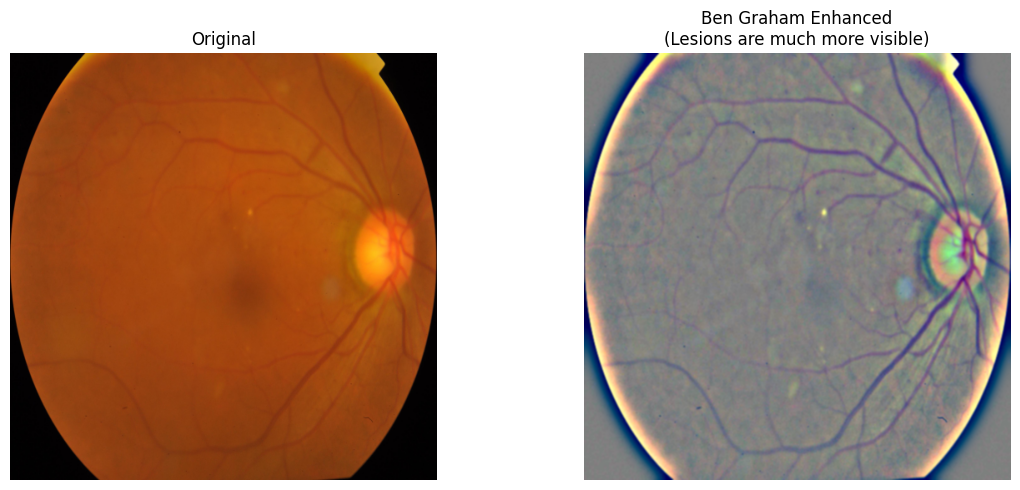

✅ Preprocessing defined


In [ ]:
def preprocess_fundus(image_path, target_size=512):
    """
    WHY each step exists:
    1. Crop black border  → removes non-retinal pixels so SLIC
                            doesn't waste superpixels on black corners
    2. Resize             → consistent size for feature extraction
    3. Ben Graham method  → THE KEY IMPROVEMENT. This is the standard
                            preprocessing used in winning Kaggle DR solutions.
                            It subtracts a blurred version of the image,
                            dramatically amplifying local contrast and making
                            microaneurysms (tiny dark red dots) and exudates
                            (bright yellow patches) pop out visually.
    4. Mild Gaussian blur → reduce sensor noise after contrast enhancement
    """
    img_bgr = cv2.imread(str(image_path))
    image   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Step 1: Remove black border
    try:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
        coords  = cv2.findNonZero(mask)
        x, y, w, h = cv2.boundingRect(coords)
        image = image[y:y+h, x:x+w]
    except Exception:
        pass

    # Step 2: Resize
    image = cv2.resize(image, (target_size, target_size),
                       interpolation=cv2.INTER_AREA)

    # Step 3: Ben Graham preprocessing (the key trick!)
    # Creates a version that highlights LOCAL contrast changes.
    # Formula: output = image * 4 + gaussian_blur * (-4) + 128
    # This is a high-pass filter — suppresses uniform background,
    # amplifies edges/lesions.
    image_float = image.astype(np.float32)
    blurred     = cv2.GaussianBlur(image_float, (0, 0), sigmaX=10)
    enhanced    = cv2.addWeighted(image_float, 4, blurred, -4, 128)
    enhanced    = np.clip(enhanced, 0, 255).astype(np.uint8)

    # Step 4: Light denoising
    result = cv2.GaussianBlur(enhanced, (3, 3), sigmaX=0)
    return result, image  # return (enhanced, original)


def show_preprocessing(image_path):
    """Visualize the preprocessing effect."""
    enhanced, original = preprocess_fundus(image_path)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(original);  axes[0].set_title("Original");  axes[0].axis("off")
    axes[1].imshow(enhanced);  axes[1].set_title("Ben Graham Enhanced\n(Lesions are much more visible)"); axes[1].axis("off")
    plt.tight_layout(); plt.show()

# Demo
sample_path = df[df["diagnosis"] == 2].iloc[0]["img_path"]
show_preprocessing(sample_path)
print("✅ Preprocessing defined")

In [ ]:
def generate_pseudo_labels_v2(image_original, segments, n_sp):
    """
    Completely rewritten pseudo-label generation.
    Key fixes:
    1. Optic disc is explicitly detected and excluded from all rules
    2. Vessel exclusion uses green/red ratio instead of just elongation
    3. Percentile thresholds computed ONLY over non-vessel, non-disc pixels
    4. Grade-0 false positives fixed by requiring BOTH darkness AND redness
    5. Peripheral dark regions fixed by tighter dist_center cutoff
    """
    H, W = image_original.shape[:2]
    img_f    = image_original.astype(np.float32) / 255.0
    gray     = cv2.cvtColor(image_original, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    img_lab  = rgb2lab(img_f)
    r_ch     = img_f[:, :, 0]
    g_ch     = img_f[:, :, 1]
    b_ch     = img_f[:, :, 2]
    L_ch     = img_lab[:, :, 0]
    B_ch     = img_lab[:, :, 2]

    # ── Step 1: Detect optic disc location ──────────────────────────
    # Optic disc = brightest compact region. Find it by looking at
    # the brightest superpixel centroid.
    sp_brightness = []
    for sp_id in range(n_sp):
        m = (segments == sp_id)
        if m.sum() == 0:
            sp_brightness.append(0.0)
            continue
        sp_brightness.append(float(gray[m].mean()))
    brightest_sp = int(np.argmax(sp_brightness))
    disc_rows, disc_cols = np.where(segments == brightest_sp)
    if len(disc_rows) > 0:
        disc_cr = disc_rows.mean() / H
        disc_cc = disc_cols.mean() / W
    else:
        disc_cr, disc_cc = 0.5, 0.5

    def near_disc(cr, cc, radius=0.12):
        return np.sqrt((cr - disc_cr)**2 + (cc - disc_cc)**2) < radius

    # ── Step 2: Identify vessel superpixels to exclude from threshold computation ──
    # Vessels: thin, dark-red, high elongation OR strong red>green with low brightness
    vessel_mask = np.zeros(n_sp, dtype=bool)
    for sp_id in range(n_sp):
        m = (segments == sp_id)
        if m.sum() == 0:
            continue
        rows, cols = np.where(m)
        # Elongation check
        sp_h = rows.max() - rows.min() + 1
        sp_w = cols.max() - cols.min() + 1
        elongation = max(sp_h / (sp_w + 1e-6), sp_w / (sp_h + 1e-6))
        mean_g = g_ch[m].mean()
        mean_r = r_ch[m].mean()
        mean_gray_sp = gray[m].mean()
        # Vessels are elongated OR very narrow dark reddish structures
        if elongation > 2.5 and mean_gray_sp < 0.45:
            vessel_mask[sp_id] = True
        # Also mark superpixels near the disc center as vessel-ish
        cr = rows.mean() / H
        cc = cols.mean() / W
        if near_disc(cr, cc, radius=0.08):
            vessel_mask[sp_id] = True

    # ── Step 3: Compute thresholds ONLY from clean retina pixels ────
    # Exclude: black border, vessels, disc, edges
    clean_mask = np.zeros((H, W), dtype=bool)
    for sp_id in range(n_sp):
        if vessel_mask[sp_id]:
            continue
        m = (segments == sp_id)
        if m.sum() == 0:
            continue
        rows, cols = np.where(m)
        cr = rows.mean() / H
        cc = cols.mean() / W
        mean_gray_sp = gray[m].mean()
        dist = np.sqrt((cr - 0.5)**2 + (cc - 0.5)**2)
        if mean_gray_sp > 0.08 and dist < 0.44 and not near_disc(cr, cc, 0.10):
            clean_mask[m] = True

    g_clean    = g_ch[clean_mask]
    gray_clean = gray[clean_mask]
    L_clean    = L_ch[clean_mask]
    B_clean    = B_ch[clean_mask]

    if len(g_clean) < 100:
        # Fallback if somehow no clean pixels
        g_clean    = g_ch[gray > 0.08]
        gray_clean = gray[gray > 0.08]
        L_clean    = L_ch[gray > 0.08]
        B_clean    = B_ch[gray > 0.08]

    # Dark thresholds: percentile of CLEAN retina (not contaminated by vessels)
    dark_p5_g    = np.percentile(g_clean, 5)
    dark_p10_g   = np.percentile(g_clean, 10)
    dark_p5_gray = np.percentile(gray_clean, 5)

    # Bright thresholds
    bright_p90_gray = np.percentile(gray_clean, 90)
    bright_p85_L    = np.percentile(L_clean, 85)
    bright_p80_B    = np.percentile(B_clean, 80)

    labels = np.full(n_sp, -1, dtype=np.int64)

    for sp_id in range(n_sp):
        m = (segments == sp_id)
        if m.sum() == 0:
            continue

        rows, cols  = np.where(m)
        cr          = rows.mean() / H
        cc          = cols.mean() / W
        dist_center = np.sqrt((cr - 0.5)**2 + (cc - 0.5)**2)
        sp_area     = m.sum()

        mean_g    = g_ch[m].mean()
        mean_r    = r_ch[m].mean()
        mean_b    = b_ch[m].mean()
        mean_gray = gray[m].mean()
        mean_L    = L_ch[m].mean()
        mean_B    = B_ch[m].mean()
        std_g     = g_ch[m].std()

        # ── Rule 1: Black border → BACKGROUND ──────────────────────
        if mean_gray < 0.08:
            labels[sp_id] = 0
            continue

        # ── Rule 2: Image edges → BACKGROUND ───────────────────────
        if dist_center > 0.43:
            labels[sp_id] = 0
            continue

        # ── Rule 3: Optic disc region → BACKGROUND ──────────────────
        # The disc is the brightest spot — definitely not a lesion
        if near_disc(cr, cc, radius=0.10):
            labels[sp_id] = 0
            continue

        # ── Rule 4: Blood vessels → BACKGROUND ──────────────────────
        if vessel_mask[sp_id]:
            labels[sp_id] = 0
            continue

        # ── Rule 5: Hemorrhages / Microaneurysms (LESION) ───────────
        # Must satisfy ALL three: dark green, reddish, small area
        # Using clean-retina percentile thresholds
        is_dark_g    = mean_g < dark_p10_g
        is_very_dark = mean_g < dark_p5_g
        is_reddish   = (mean_r > mean_g * 1.20)   # strong R > G
        is_small     = sp_area < (H * W * 0.012)  # < 1.2% of image

        # Elongation (vessels that slipped through vessel_mask)
        sp_h = rows.max() - rows.min() + 1
        sp_w = cols.max() - cols.min() + 1
        elongation = max(sp_h / (sp_w + 1e-6), sp_w / (sp_h + 1e-6))
        not_elongated = elongation < 3.0

        if is_dark_g and is_reddish and is_small and not_elongated:
            labels[sp_id] = 1
            continue

        # Microaneurysms: very dark, any redness
        rg_ratio = mean_r / (mean_g + 1e-6)
        if is_very_dark and rg_ratio > 1.08 and is_small and not_elongated:
            labels[sp_id] = 1
            continue

        # ── Rule 6: Exudates (LESION) ───────────────────────────────
        # Bright, yellowish, not the optic disc
        # Use clean-retina bright thresholds
        is_bright  = mean_gray > bright_p90_gray
        is_bright_L = mean_L > bright_p85_L
        is_yellow  = mean_B > bright_p80_B   # above 80th percentile of B*

        # Exudates must also be clearly yellow (B* > 5 in absolute LAB)
        is_abs_yellow = mean_B > 5.0

        if is_bright and is_abs_yellow and not near_disc(cr, cc, 0.12):
            labels[sp_id] = 1
            continue

        if is_bright_L and is_yellow and is_abs_yellow and not near_disc(cr, cc, 0.12):
            labels[sp_id] = 1
            continue

        # ── Rule 7: Clearly normal retina → BACKGROUND ─────────────
        # Normal retina: medium brightness, orange-ish, uniform
        is_medium   = 0.25 < mean_gray < 0.70
        is_orangeish = (mean_r > mean_b * 1.1) and (mean_r > mean_g * 0.88)
        is_uniform  = std_g < 0.06

        if is_medium and is_orangeish and is_uniform:
            labels[sp_id] = 0
            continue

        # Medium brightness orange retina (less strict)
        if is_medium and (mean_r > mean_b):
            labels[sp_id] = 0
            continue

        # Anything not confidently classified → uncertain

    n_lesion = int((labels == 1).sum())
    n_bg     = int((labels == 0).sum())
    n_unc    = int((labels == -1).sum())

    print(f"   Pseudo-labels → Lesion:{n_lesion:>4} | "
          f"Background:{n_bg:>4} | Uncertain:{n_unc:>4} | Total:{n_sp}")

    return torch.tensor(labels, dtype=torch.long), n_lesion

In [ ]:
def generate_superpixels(image, n_segments=200, compactness=8, sigma=1):
    """
    WHY LAB color space: SLIC in LAB groups pixels by perceptual
    similarity. Lesions (which differ in color from normal retina)
    get their own superpixels rather than being merged into background.
    sigma=1: slight smoothing before SLIC helps ignore tiny noise.
    """
    image_lab = rgb2lab(image.astype(np.float32) / 255.0)
    segments  = slic(image_lab, n_segments=n_segments,
                     compactness=compactness, sigma=sigma,
                     start_label=0, channel_axis=-1)
    return segments, int(segments.max() + 1)

In [ ]:
def extract_features_v2(image_original, image_enhanced, segments, n_sp):
    """
    We now extract features from BOTH the original and enhanced images.
    Total features per node: 32

    Why use both images?
    - Original: reliable color information (R/G ratio, LAB values)
    - Enhanced: lesion regions have HIGH contrast → high std, high range
                Normal retina has LOW contrast → low std after enhancement

    Feature groups:
    [0-2]   Mean RGB (original)          — baseline color
    [3-5]   Std  RGB (original)          — color uniformity
    [6-8]   Mean LAB (original)          — perceptual color
    [9-10]  Green channel mean, std      — dark lesions show in green
    [11-12] Red channel mean, std        — hemorrhages are reddish
    [13]    Red/green ratio              — lesion vs normal discriminator
    [14]    B* channel in LAB            — yellow = exudates
    [15]    L* channel in LAB            — brightness
    [16-18] Mean RGB (enhanced)          — contrast-amplified color
    [19-21] Std  RGB (enhanced)          — HIGH std in enhanced = lesion!
    [22]    Green std in enhanced        — key lesion indicator
    [23]    Intensity range (enhanced)   — max-min = lesion contrast
    [24-25] Normalized centroid (r, c)   — spatial position
    [26]    Distance from center         — lesions mostly in center
    [27]    Normalized area              — lesion size feature
    [28]    Border flag                  — border = background
    [29]    Green channel min (original) — very dark green = hemorrhage
    [30]    Gray mean                    — overall brightness
    [31]    Gray std                     — texture / uniformity
    """
    H, W = image_original.shape[:2]

    # Pre-compute all maps
    orig_f = image_original.astype(np.float32) / 255.0
    enh_f  = image_enhanced.astype(np.float32) / 255.0
    orig_lab = rgb2lab(orig_f)
    gray   = cv2.cvtColor(image_original, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

    features  = []
    centroids = []

    for sp_id in range(n_sp):
        mask = (segments == sp_id)
        if mask.sum() == 0:
            features.append(np.zeros(32, dtype=np.float32))
            centroids.append((H//2, W//2))
            continue

        # Original image pixels
        orig_pix = orig_f[mask]
        lab_pix  = orig_lab[mask]
        enh_pix  = enh_f[mask]
        gray_pix = gray[mask]

        # Spatial
        rows, cols  = np.where(mask)
        cr          = rows.mean() / H
        cc          = cols.mean() / W
        dist_center = np.sqrt((cr - 0.5)**2 + (cc - 0.5)**2)
        norm_area   = mask.sum() / (H * W)
        border      = float(rows.min() < 8 or rows.max() > H-8 or
                            cols.min() < 8 or cols.max() > W-8)

        # Original color features
        mean_rgb_o = orig_pix.mean(axis=0)   # (3,)
        std_rgb_o  = orig_pix.std(axis=0)    # (3,)
        mean_lab   = lab_pix.mean(axis=0)    # L, a, b

        g_pix = orig_pix[:, 1]
        r_pix = orig_pix[:, 0]
        rg_ratio = mean_rgb_o[0] / (mean_rgb_o[1] + 1e-6)

        # Enhanced image features
        mean_rgb_e = enh_pix.mean(axis=0)
        std_rgb_e  = enh_pix.std(axis=0)
        g_enh      = enh_pix[:, 1]
        intensity_range = enh_pix.max() - enh_pix.min()

        feat = np.array([
            *mean_rgb_o,           # 0-2
            *std_rgb_o,            # 3-5
            *mean_lab,             # 6-8
            g_pix.mean(),          # 9
            g_pix.std(),           # 10
            r_pix.mean(),          # 11
            r_pix.std(),           # 12
            rg_ratio,              # 13
            mean_lab[2],           # 14  B* (yellow)
            mean_lab[0],           # 15  L* (brightness)
            *mean_rgb_e,           # 16-18
            *std_rgb_e,            # 19-21
            g_enh.std(),           # 22  green std in enhanced
            float(intensity_range),# 23
            cr, cc,                # 24-25
            dist_center,           # 26
            norm_area,             # 27
            border,                # 28
            g_pix.min(),           # 29  min green
            gray_pix.mean(),       # 30
            gray_pix.std(),        # 31
        ], dtype=np.float32)

        features.append(feat)
        centroids.append((rows.mean(), cols.mean()))

    return np.array(features, dtype=np.float32), centroids

In [ ]:
def build_knn_graph_v2(features, centroids, k=8):
    """
    k=8 gives each node more neighbours → richer message passing.
    We also add edge features (distance) as the GATConv uses them.
    """
    n = len(centroids)
    if n < 2:
        return Data(
            x=torch.zeros(1, features.shape[1]),
            edge_index=torch.zeros(2, 0, dtype=torch.long),
            edge_attr=torch.zeros(0, 1)
        )

    coords   = np.array(centroids, dtype=np.float32)
    k_actual = min(k + 1, n)

    nbrs = NearestNeighbors(n_neighbors=k_actual, algorithm="ball_tree")
    nbrs.fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    src, dst, wts = [], [], []
    for i in range(n):
        for j in range(1, k_actual):
            src.append(i)
            dst.append(int(indices[i, j]))
            wts.append(float(distances[i, j]))

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_attr  = torch.tensor(wts, dtype=torch.float32).unsqueeze(1)

    # Normalize features: zero-mean, unit-std per feature column
    x    = torch.tensor(features, dtype=torch.float32)
    mean = x.mean(dim=0, keepdim=True)
    std  = x.std(dim=0, keepdim=True).clamp(min=1e-8)
    x    = (x - mean) / std

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

In [ ]:
class LesionGAT_v2(nn.Module):
    """
    Key improvements over the original:

    1. LARGER hidden dim (128 vs 64) → more representational capacity
    2. MORE HEADS (4 vs 2) → attention can specialize to different
       lesion types simultaneously
    3. RESIDUAL CONNECTIONS → prevents gradient vanishing in deeper nets
    4. LAYER NORM instead of BatchNorm → more stable with small graphs
    5. DROPOUT in attention → reduces overfitting to pseudo-labels
    6. TWO-LAYER CLASSIFIER HEAD → richer decision boundary

    Architecture:
        Input (32 features) → Linear projection → 3x GAT layers → Classifier
    """

    def __init__(self, in_channels, hidden=128,
                 n_classes=2, n_layers=3, heads=4, dropout=0.2):
        super().__init__()
        self.dropout = dropout

        # Input projection
        self.proj = nn.Sequential(
            nn.Linear(in_channels, hidden),
            nn.LayerNorm(hidden),
            nn.ELU(),
            nn.Dropout(dropout)
        )

        # GAT layers with residual connections
        self.convs    = nn.ModuleList()
        self.norms    = nn.ModuleList()
        self.proj_res = nn.ModuleList()  # residual projections

        for i in range(n_layers):
            in_ch = hidden * heads if i > 0 else hidden
            self.convs.append(
                GATConv(in_ch, hidden, heads=heads,
                        dropout=dropout, concat=True)
            )
            self.norms.append(nn.LayerNorm(hidden * heads))
            # Project residual to match GAT output dimension
            self.proj_res.append(
                nn.Linear(in_ch, hidden * heads, bias=False)
                if in_ch != hidden * heads else nn.Identity()
            )

        final_dim = hidden * heads

        # Two-layer classifier (richer decision boundary)
        self.clf = nn.Sequential(
            nn.Linear(final_dim, final_dim // 2),
            nn.LayerNorm(final_dim // 2),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(final_dim // 2, n_classes)
        )

    def forward(self, x, edge_index, edge_attr=None, batch=None):
        x = self.proj(x)

        for conv, norm, proj_r in zip(self.convs, self.norms, self.proj_res):
            residual = proj_r(x)          # project x to match output shape
            h = conv(x, edge_index)
            h = norm(h)
            h = F.elu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            x = h + residual              # residual connection

        return self.clf(x)

In [ ]:
def train_one_image_v2(image_path, device=DEVICE):
    """
    Full pipeline with all improvements.

    KEY CHANGE in training:
    - Dynamic class weight: instead of fixed [1.0, 5.0], we compute
      it from the actual pseudo-label ratio in THIS image.
      If there are 5 lesion and 200 background superpixels,
      weight = [1.0, 200/5] = [1.0, 40.0].
      This prevents the model from always predicting background.

    - Label smoothing: softens the training targets slightly,
      making the model less overconfident on uncertain pseudo-labels.
    """
    # 1. Preprocess — get BOTH enhanced and original
    enhanced, original = preprocess_fundus(image_path, target_size=IMG_SIZE)

    # 2. SLIC on enhanced image (lesions more visible → better boundaries)
    segments, n_sp = generate_superpixels(enhanced, N_SEGMENTS, COMPACTNESS)

    # 3. Features from BOTH images
    features, centroids = extract_features_v2(original, enhanced, segments, n_sp)

    # 4. Build graph
    graph = build_knn_graph_v2(features, centroids, k=K_NEIGHBOURS).to(device)

    # 5. Pseudo-labels on ORIGINAL image (accurate colors)
    pseudo, n_lesion = generate_pseudo_labels_v2(original, segments, n_sp)
    pseudo = pseudo.to(device)
    mask   = (pseudo != -1)
    n_confident = mask.sum().item()

    if n_confident < 5:
        print("   ⚠️  Too few confident labels — skipping")
        return original, segments, np.zeros(n_sp), np.zeros(n_sp), []

    # 6. Dynamic class weight based on actual ratio
    n_bg_labels  = (pseudo[mask] == 0).sum().item()
    n_les_labels = (pseudo[mask] == 1).sum().item()
    if n_les_labels == 0:
        print("   ⚠️  No lesion pseudo-labels found")
        # Still train but with default weight
        les_weight = 10.0
    else:
        # Weight inversely proportional to class frequency
        les_weight = min(n_bg_labels / (n_les_labels + 1e-6), 50.0)
        les_weight = max(les_weight, 5.0)  # at least 5x
    cls_w = torch.tensor([1.0, les_weight], device=device)
    print(f"   Class weight: [BG=1.0, Lesion={les_weight:.1f}]  "
          f"(BG={n_bg_labels}, Lesion={n_les_labels})")

    # 7. Model + optimizer
    in_ch = graph.x.shape[1]
    model = LesionGAT_v2(in_ch, HIDDEN_DIM, 2, NUM_LAYERS, NUM_HEADS, DROPOUT).to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-5)

    # 8. Training loop with label smoothing
    loss_curve = []
    model.train()
    for ep in range(EPOCHS):
        opt.zero_grad()
        logits = model(graph.x, graph.edge_index, graph.edge_attr)

        # Label smoothing: mix ground truth with uniform distribution
        # smoothing=0.1 means 90% true label + 10% other class
        smooth = 0.1
        n_cls  = 2
        targets = pseudo[mask].float()
        # Soft targets
        soft_targets = targets * (1 - smooth) + smooth / n_cls

        # Weighted cross-entropy with soft targets
        log_probs = F.log_softmax(logits[mask], dim=1)
        # Expand soft_targets to 2-class format
        soft_2class = torch.stack([1 - soft_targets, soft_targets], dim=1)
        # Apply class weights
        weights = cls_w[pseudo[mask]]
        loss = -(soft_2class * log_probs).sum(dim=1)
        loss = (loss * weights).mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        opt.step()
        sched.step()
        loss_curve.append(loss.item())

    # 9. Inference
    model.eval()
    with torch.no_grad():
        logits = model(graph.x, graph.edge_index, graph.edge_attr)
        probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = (probs > 0.45).astype(np.int64)  # lower threshold to catch
                                                    # more lesion SPs   # slightly lower threshold
                                                    # since lesions are rare

    print(f"   Final loss: {loss_curve[-1]:.4f} | "
          f"Predicted lesion SPs: {preds.sum()}/{n_sp}")
    return original, segments, preds, probs, loss_curve

In [ ]:
def plot_results_v2(image, segments, preds, probs, loss_curve,
                    pseudo_labels=None, title=""):
    """
    5-panel plot (added pseudo-label visualization so you can verify
    the pseudo-labels look correct before trusting the GNN output).
    """
    H, W = image.shape[:2]
    n_sp = len(preds)

    pred_map = np.zeros((H, W), dtype=np.uint8)
    prob_map = np.zeros((H, W), dtype=np.float32)
    for sp_id in range(n_sp):
        m = (segments == sp_id)
        pred_map[m] = int(preds[sp_id])
        prob_map[m] = float(probs[sp_id])

    ncols = 5 if pseudo_labels is not None else 4
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
    fig.suptitle(title, fontsize=13)

    col = 0

    # Panel 1: Original
    axes[col].imshow(image)
    axes[col].set_title("Original Fundus"); axes[col].axis("off")
    col += 1

    # Panel 2: Pseudo-labels (if available)
    if pseudo_labels is not None:
        pseudo_map = np.zeros((H, W, 3), dtype=np.float32)
        for sp_id in range(n_sp):
            m = (segments == sp_id)
            lbl = pseudo_labels[sp_id].item() if hasattr(pseudo_labels[sp_id], 'item') else pseudo_labels[sp_id]
            if lbl == 1:
                pseudo_map[m] = [1.0, 0.3, 0.3]   # red = lesion
            elif lbl == 0:
                pseudo_map[m] = [0.3, 0.8, 0.3]   # green = background
            else:
                pseudo_map[m] = [0.5, 0.5, 0.5]   # gray = uncertain
        axes[col].imshow(pseudo_map)
        axes[col].set_title("Pseudo-labels\n(Red=Lesion, Green=BG, Gray=Uncertain)")
        axes[col].axis("off"); col += 1

    # Panel 3: Detected lesions overlay
    overlay = image.astype(np.float32) / 255.0
    lesion_px = pred_map.astype(bool)
    overlay[lesion_px] = overlay[lesion_px] * 0.3 + np.array([1.0, 0.1, 0.1]) * 0.7
    axes[col].imshow(np.clip(overlay, 0, 1))
    axes[col].set_title(f"Detected Lesions\n({int(preds.sum())}/{n_sp} SPs)")
    axes[col].axis("off"); col += 1

    # Panel 4: Probability heatmap
    im = axes[col].imshow(prob_map, cmap="hot", vmin=0, vmax=1)
    plt.colorbar(im, ax=axes[col], fraction=0.046, pad=0.04)
    axes[col].set_title("Lesion Probability Map"); axes[col].axis("off"); col += 1

    # Panel 5: Loss curve
    axes[col].plot(loss_curve, color="steelblue", lw=1.5)
    axes[col].set_title("Training Loss")
    axes[col].set_xlabel("Epoch"); axes[col].set_ylabel("Loss")
    axes[col].grid(True, alpha=0.3); col += 1

    plt.tight_layout()
    plt.show()


def plot_superpixel_graph_v2(image, centroids, edge_index, preds, max_edges=500):
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.imshow(image)
    n_edges = edge_index.shape[1]
    step    = max(1, n_edges // max_edges)
    for i in range(0, n_edges, step):
        s, d = edge_index[0, i], edge_index[1, i]
        r1, c1 = centroids[s]; r2, c2 = centroids[d]
        ax.plot([c1, c2], [r1, r2], "w-", lw=0.3, alpha=0.3)
    colors = ["red" if preds[i] == 1 else "lime" for i in range(len(centroids))]
    rs = [c[0] for c in centroids]; cs = [c[1] for c in centroids]
    ax.scatter(cs, rs, s=12, c=colors, zorder=5)
    ax.set_title("Superpixel Graph  (Red=Lesion, Green=Normal)"); ax.axis("off")
    plt.tight_layout(); plt.show()

=== PSEUDO-LABEL VERIFICATION ===
Checking one image per grade...

   Pseudo-labels → Lesion:  14 | Background: 114 | Uncertain:   8 | Total:136


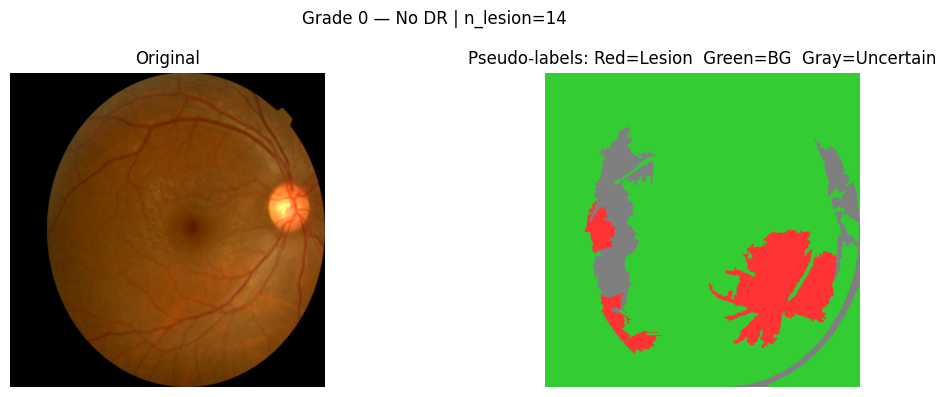

   Pseudo-labels → Lesion:  17 | Background: 111 | Uncertain:  40 | Total:168


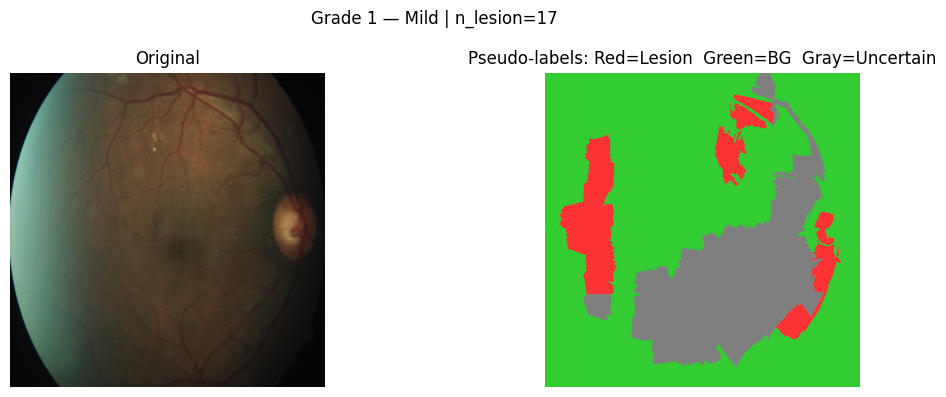

   Pseudo-labels → Lesion:  21 | Background: 130 | Uncertain:   0 | Total:151


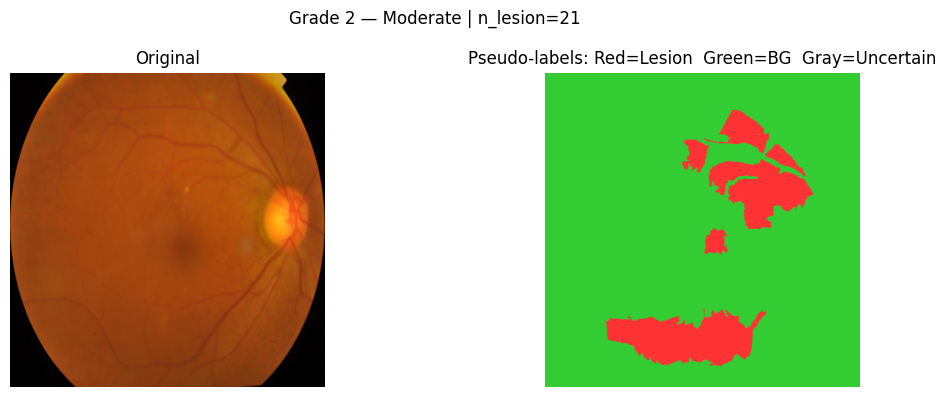

   Pseudo-labels → Lesion:  15 | Background: 107 | Uncertain:  25 | Total:147


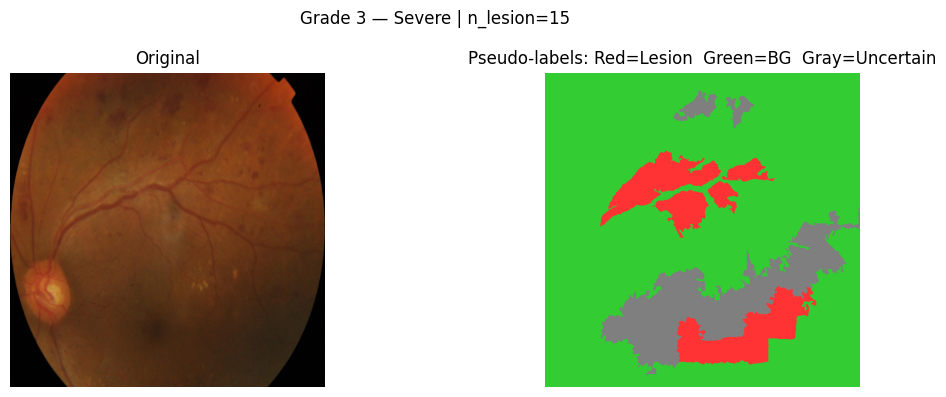

   Pseudo-labels → Lesion:  14 | Background: 138 | Uncertain:   1 | Total:153


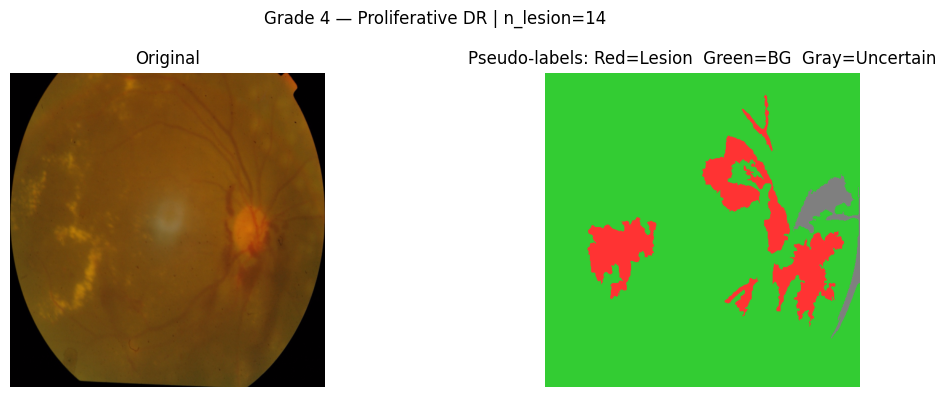

In [ ]:
print("=== PSEUDO-LABEL VERIFICATION ===")
print("Checking one image per grade...\n")

for grade in range(5):
    row  = df[df["diagnosis"] == grade].iloc[0]
    path = row["img_path"]
    enhanced, original = preprocess_fundus(path)
    segs, n_sp = generate_superpixels(enhanced)
    feats, cents = extract_features_v2(original, enhanced, segs, n_sp)
    pseudo, n_les = generate_pseudo_labels_v2(original, segs, n_sp)

    H, W = original.shape[:2]
    vis  = np.zeros((H, W, 3), dtype=np.float32)
    for sp_id in range(n_sp):
        m = (segs == sp_id)
        lbl = pseudo[sp_id].item()
        if lbl == 1: vis[m] = [1.0, 0.2, 0.2]
        elif lbl == 0: vis[m] = [0.2, 0.8, 0.2]
        else: vis[m] = [0.5, 0.5, 0.5]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Grade {grade} — {GRADE_LABELS[grade]} | n_lesion={n_les}", fontsize=12)
    axes[0].imshow(original); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(vis)
    axes[1].set_title("Pseudo-labels: Red=Lesion  Green=BG  Gray=Uncertain")
    axes[1].axis("off")
    plt.tight_layout(); plt.show()

Running on: 1bea04b2bb2d  Grade 2 — Moderate
───────────────────────────────────────────────────────
   Pseudo-labels → Lesion:  16 | Background: 123 | Uncertain:   0 | Total:139
   Pseudo-labels → Lesion:  16 | Background: 104 | Uncertain:   0 | Total:120
   Class weight: [BG=1.0, Lesion=6.5]  (BG=104, Lesion=16)
   Final loss: 0.4109 | Predicted lesion SPs: 17/120


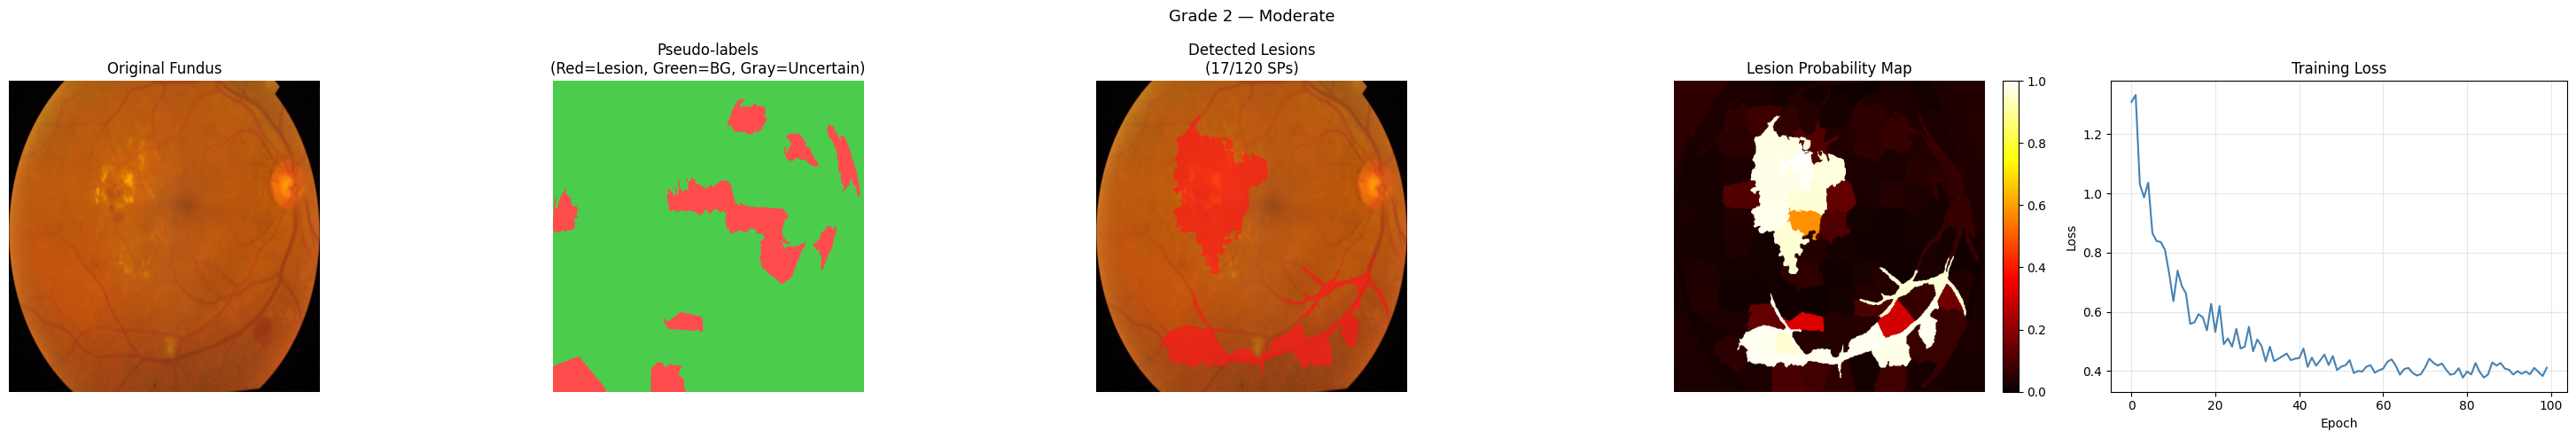

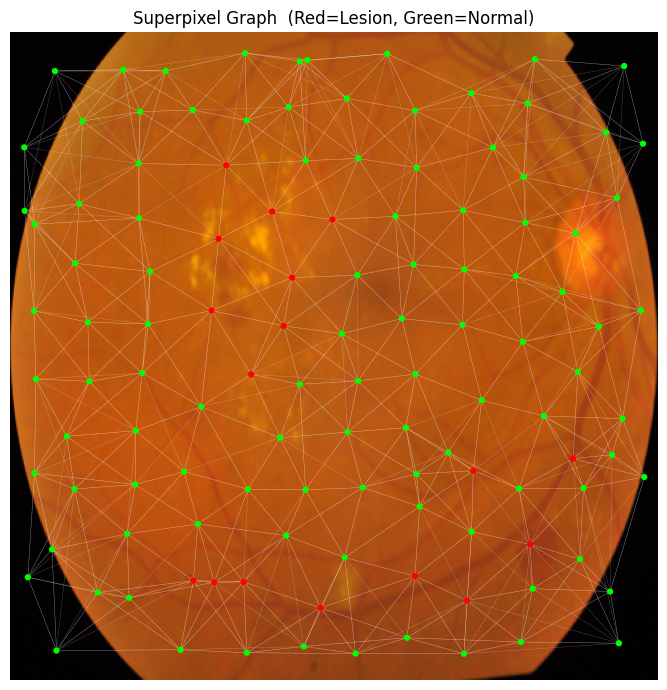

In [ ]:
sample_row  = df[df["diagnosis"] == 2].iloc[3]
sample_path = sample_row["img_path"]

print(f"Running on: {sample_row['id_code']}  "
      f"Grade {sample_row['diagnosis']} — {sample_row['grade_name']}")
print("─" * 55)

# Get pseudo-labels for visualization
enhanced_s, original_s = preprocess_fundus(sample_path)
segs_s, n_sp_s = generate_superpixels(enhanced_s)
feats_s, cents_s = extract_features_v2(original_s, enhanced_s, segs_s, n_sp_s)
pseudo_s, _ = generate_pseudo_labels_v2(original_s, segs_s, n_sp_s)

# Full training pipeline
image_out, segs_out, preds_out, probs_out, losses = train_one_image_v2(
    sample_path, device=DEVICE
)

# Rebuild centroids for graph plot
# Rebuild centroids using SAME segmentation
n_sp_r = len(np.unique(segs_out))

_, cents_r = extract_features_v2(
    image_out,
    image_out,
    segs_out,
    n_sp_r
)

# Ensure counts match predictions
min_nodes = min(len(cents_r), len(preds_out))

cents_r  = cents_r[:min_nodes]
preds_out = preds_out[:min_nodes]

g_r = build_knn_graph_v2(
    np.zeros((min_nodes, 32)),
    cents_r
)

plot_results_v2(
    image_out, segs_out, preds_out, probs_out, losses,
    pseudo_labels=pseudo_s,
    title=f"Grade {sample_row['diagnosis']} — {sample_row['grade_name']}"
)
plot_superpixel_graph_v2(image_out, cents_r, g_r.edge_index.numpy(), preds_out)


Processing Grade 0: No DR
   Pseudo-labels → Lesion:   7 | Background:  97 | Uncertain:   1 | Total:105
   Class weight: [BG=1.0, Lesion=13.9]  (BG=97, Lesion=7)
   Final loss: 0.4151 | Predicted lesion SPs: 8/105
   Pseudo-labels → Lesion:   9 | Background: 113 | Uncertain:   0 | Total:122


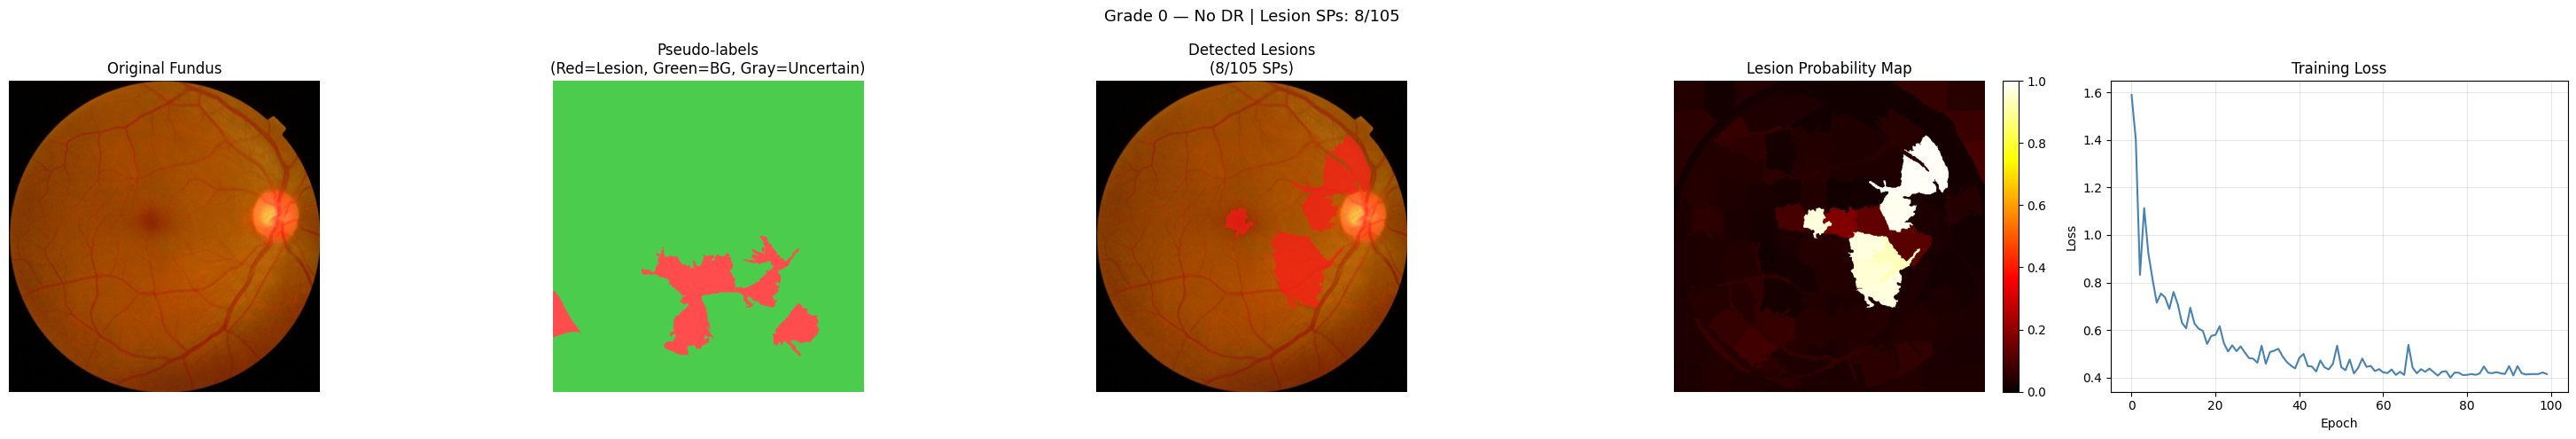


Processing Grade 1: Mild
   Pseudo-labels → Lesion:  11 | Background: 106 | Uncertain:   0 | Total:117
   Class weight: [BG=1.0, Lesion=9.6]  (BG=106, Lesion=11)
   Final loss: 0.4403 | Predicted lesion SPs: 11/117
   Pseudo-labels → Lesion:  13 | Background: 121 | Uncertain:   0 | Total:134


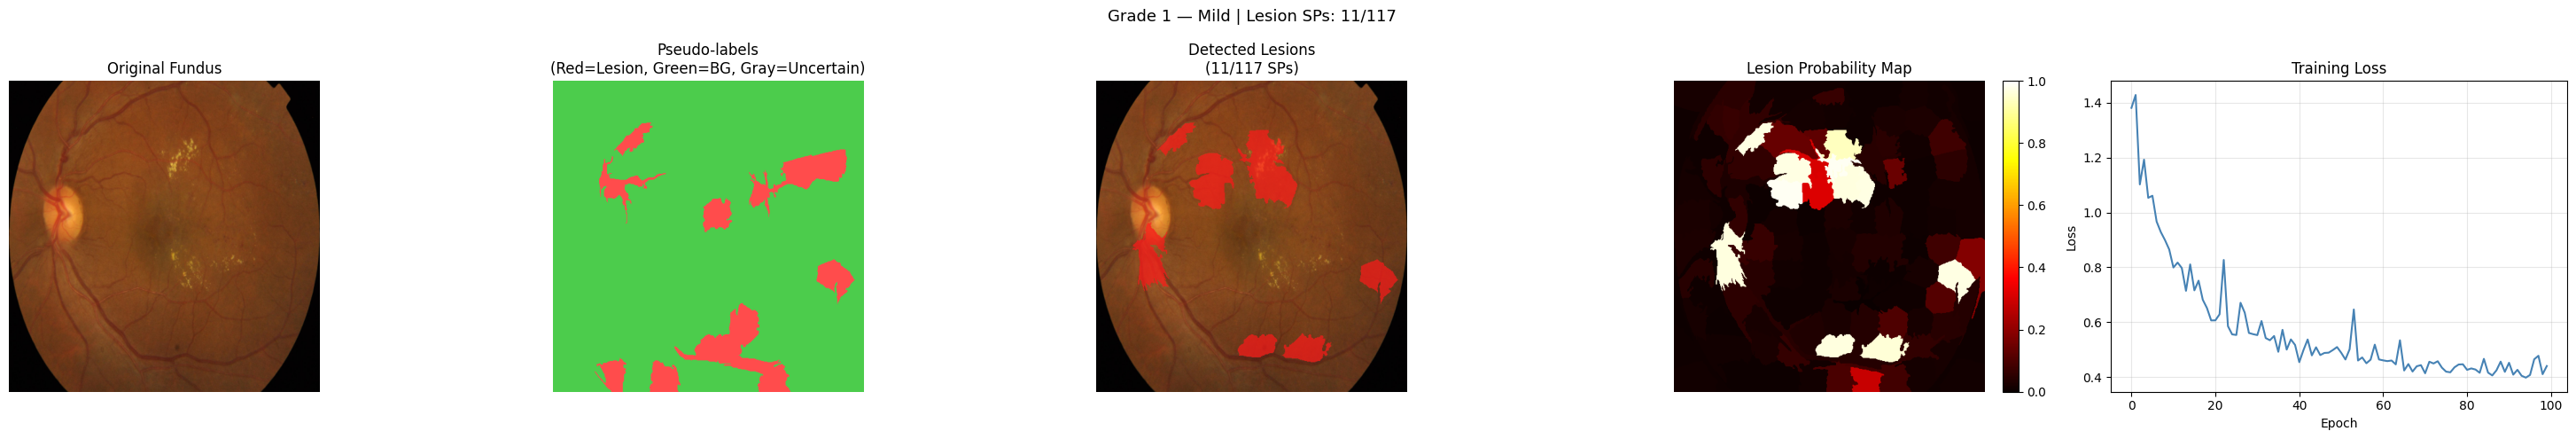


Processing Grade 2: Moderate
   Pseudo-labels → Lesion:   8 | Background: 109 | Uncertain:   0 | Total:117
   Class weight: [BG=1.0, Lesion=13.6]  (BG=109, Lesion=8)
   Final loss: 0.3981 | Predicted lesion SPs: 10/117
   Pseudo-labels → Lesion:   8 | Background: 136 | Uncertain:   0 | Total:144


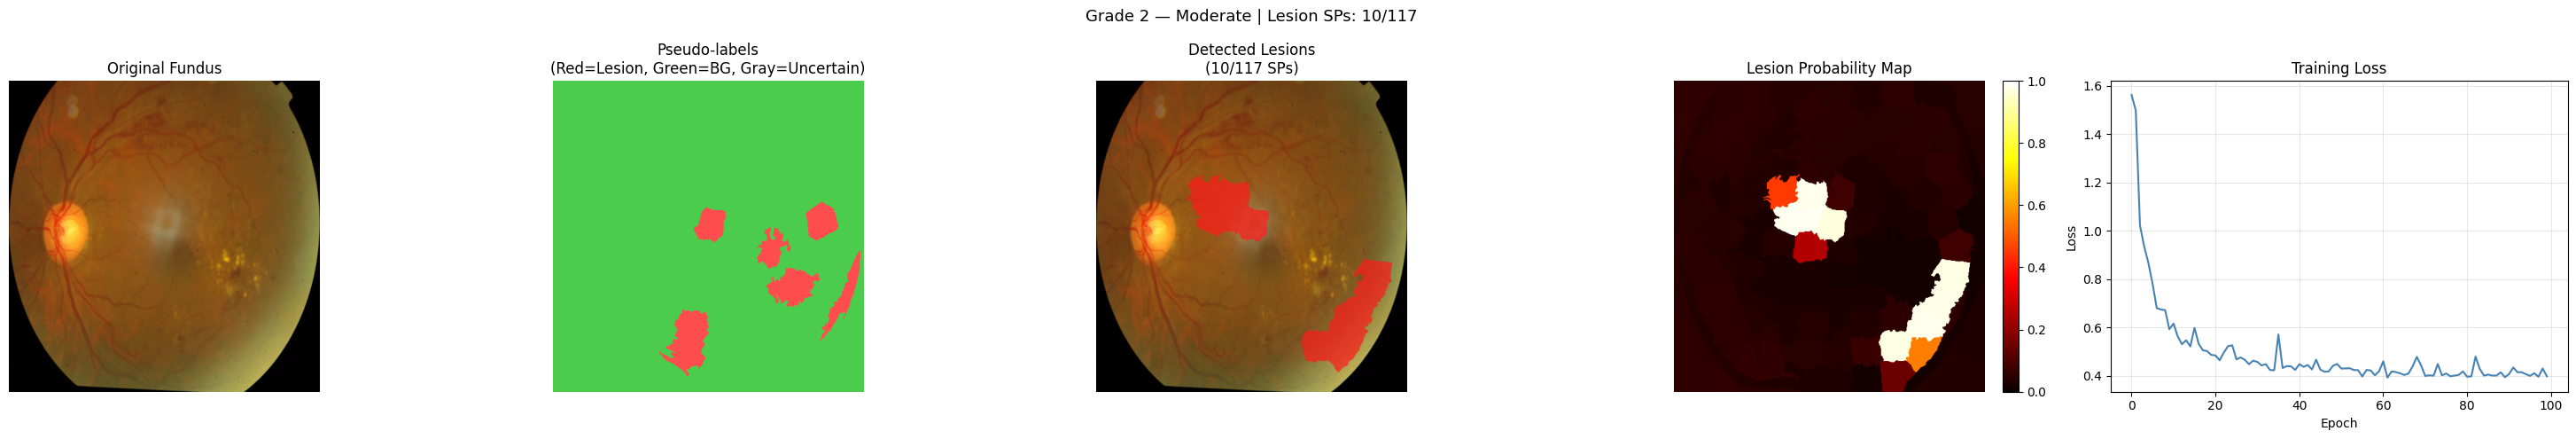


Processing Grade 3: Severe
   Pseudo-labels → Lesion:   9 | Background:  98 | Uncertain:   0 | Total:107
   Class weight: [BG=1.0, Lesion=10.9]  (BG=98, Lesion=9)
   Final loss: 0.4636 | Predicted lesion SPs: 12/107
   Pseudo-labels → Lesion:  11 | Background: 111 | Uncertain:   0 | Total:122


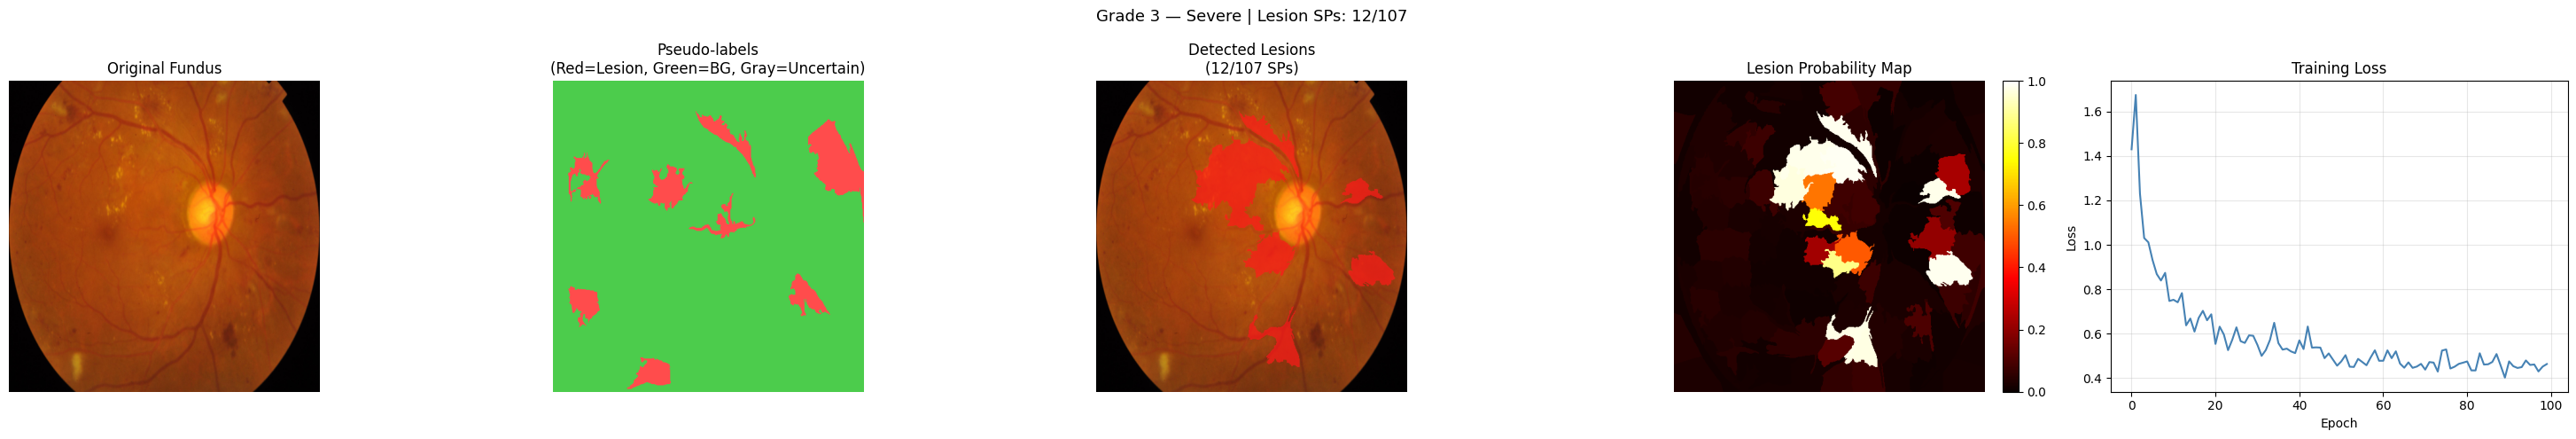


Processing Grade 4: Proliferative DR
   Pseudo-labels → Lesion:  16 | Background:  99 | Uncertain:  11 | Total:126
   Class weight: [BG=1.0, Lesion=6.2]  (BG=99, Lesion=16)
   Final loss: 0.3733 | Predicted lesion SPs: 18/126
   Pseudo-labels → Lesion:  21 | Background: 129 | Uncertain:  12 | Total:162


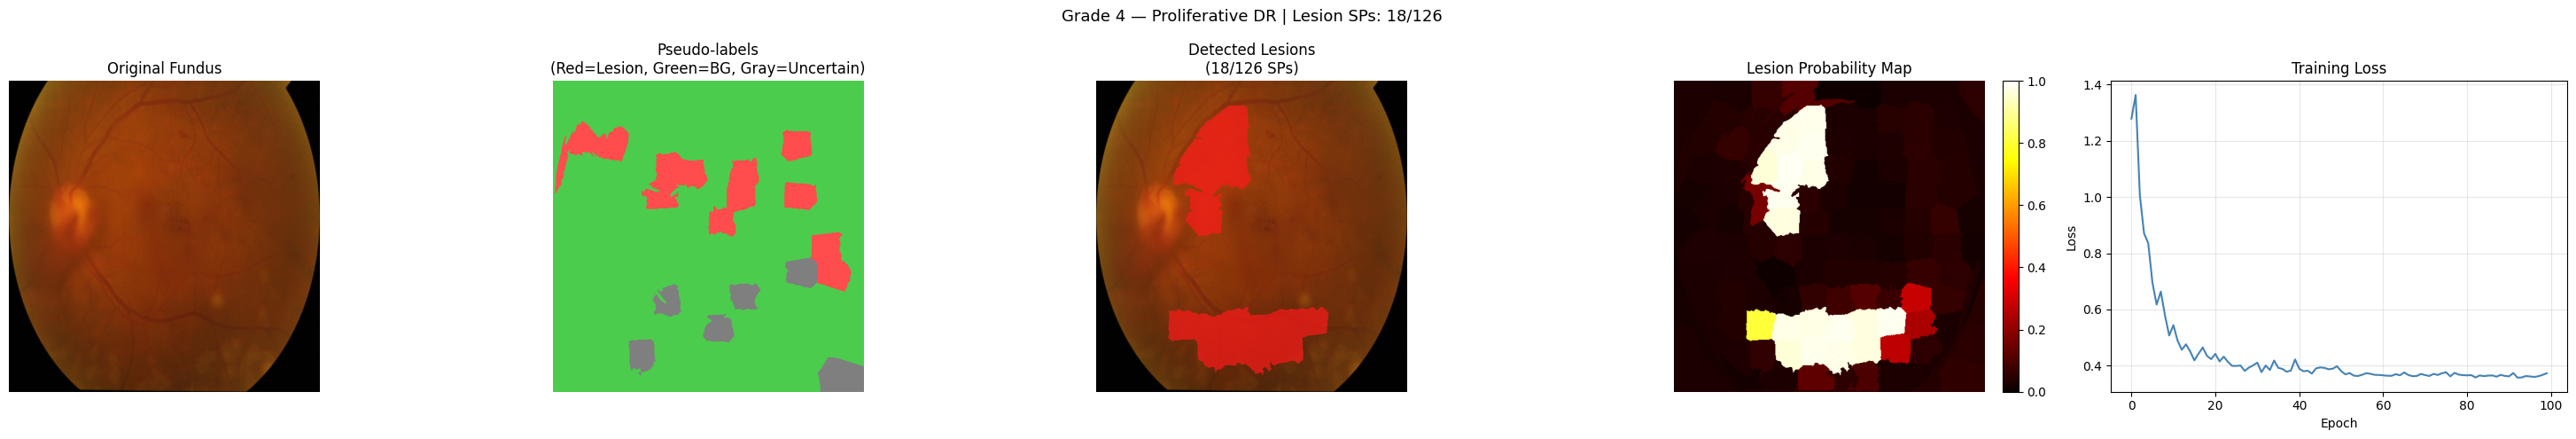


✅ All grades processed

📊 Results Summary:
 grade       grade_name  n_sp  lesion_sp  lesion_pct  final_loss
     0            No DR   105          8        7.62      0.4151
     1             Mild   117         11        9.40      0.4403
     2         Moderate   117         10        8.55      0.3981
     3           Severe   107         12       11.21      0.4636
     4 Proliferative DR   126         18       14.29      0.3733


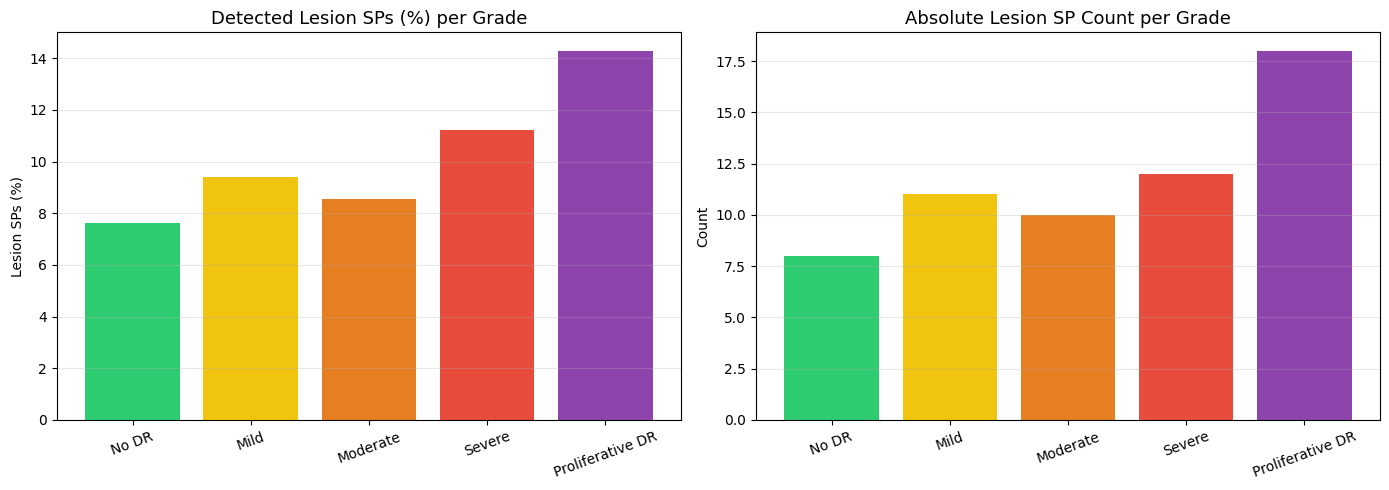

In [ ]:
results_summary = []

for grade in range(5):
    print(f"\n{'='*55}")
    print(f"Processing Grade {grade}: {GRADE_LABELS[grade]}")
    print(f"{'='*55}")

    row  = df[df["diagnosis"] == grade].iloc[1]
    path = row["img_path"]

    image_g, segs_g, preds_g, probs_g, losses_g = train_one_image_v2(
        path, device=DEVICE
    )

    # Also get pseudo labels for display
    enh_g, orig_g = preprocess_fundus(path)
    segs_g2, n_sp_g2 = generate_superpixels(enh_g)
    _, _ = extract_features_v2(orig_g, enh_g, segs_g2, n_sp_g2)
    pseudo_g, _ = generate_pseudo_labels_v2(orig_g, segs_g2, n_sp_g2)

    lesion_pct = 100.0 * preds_g.sum() / len(preds_g)
    results_summary.append({
        "grade"      : grade,
        "grade_name" : GRADE_LABELS[grade],
        "n_sp"       : len(preds_g),
        "lesion_sp"  : int(preds_g.sum()),
        "lesion_pct" : round(lesion_pct, 2),
        "final_loss" : round(losses_g[-1], 4) if losses_g else 0,
    })

    plot_results_v2(
        image_g, segs_g, preds_g, probs_g, losses_g,
        pseudo_labels=pseudo_g,
        title=f"Grade {grade} — {GRADE_LABELS[grade]} | Lesion SPs: {int(preds_g.sum())}/{len(preds_g)}"
    )

print("\n✅ All grades processed")
results_df = pd.DataFrame(results_summary)
print("\n📊 Results Summary:")
print(results_df.to_string(index=False))

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_grade = ["#2ecc71","#f1c40f","#e67e22","#e74c3c","#8e44ad"]
axes[0].bar(results_df["grade_name"], results_df["lesion_pct"], color=colors_grade)
axes[0].set_title("Detected Lesion SPs (%) per Grade", fontsize=13)
axes[0].set_ylabel("Lesion SPs (%)"); axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)
axes[1].bar(results_df["grade_name"], results_df["lesion_sp"], color=colors_grade)
axes[1].set_title("Absolute Lesion SP Count per Grade", fontsize=13)
axes[1].set_ylabel("Count"); axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()